In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 14. 付録: 特徴量選択

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語。

## この章で分かること

- なぜ特徴を選ぶのか(次元の呪い・過学習・速度・解釈性)
- 三つの系統:
  - **Filter**(モデル非依存): 分散しきい値・単変量検定(F 値 / 相互情報量)
  - **Wrapper**(モデルで評価): RFE / RFECV
  - **Embedded**(学習に内在): L1(Lasso)・木の重要度 → `SelectFromModel`
- 選択した特徴数と性能の関係、**選択の安定性**
- 最重要: **特徴選択は交差検証の内側(訓練のみ)で行う**(04 章のリークの再演)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)

bc = datasets.load_breast_cancer_dataset()
# Dilute the 30 real features with 20 pure-noise features (irrelevant to the label).
rng = np.random.default_rng(0)
noise = rng.standard_normal((len(bc.data), 20))
X = np.hstack([bc.data.to_numpy(), noise])
feat_names = list(bc.feature_names) + [f"noise_{i}" for i in range(20)]
y = bc.target.to_numpy()
print(f"X shape: {X.shape}  (30 real + 20 noise features)")

X shape: (569, 50)  (30 real + 20 noise features)


## 1. なぜ選ぶのか

無関係な特徴は、過学習を招き、学習を遅くし、解釈を難しくします。ノイズ特徴を足したデータで、
**全特徴 vs 真の 30 特徴のみ** の交差検証精度を比べます。

In [3]:
all_feats = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)), X, y, cv=5).mean()
real_only = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000)), X[:, :30], y, cv=5).mean()
print(f"all 50 features  CV acc: {all_feats:.3f}")
print(f"real 30 features CV acc: {real_only:.3f}   <- noise features add variance, not signal")

all 50 features  CV acc: 0.963
real 30 features CV acc: 0.981   <- noise features add variance, not signal


## 2. Filter — モデル非依存の事前選択

- **VarianceThreshold**: ほぼ定数の特徴を捨てる(超低分散=情報なし)。
- **単変量検定**: 各特徴と目的変数の関係を個別に採点。`f_classif`(線形な分離)や
  `mutual_info_classif`(非線形も拾う)で上位 k 個を選ぶ。

注意: filter は特徴を **個別** に見るので、組み合わせて効く特徴(相互作用)を見落とすことがあります。

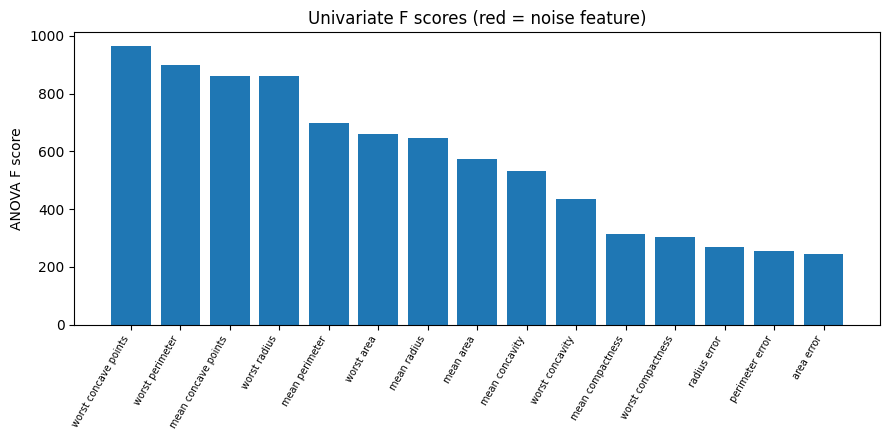

noise features in top 15 by F score: 0


In [4]:
from sklearn.feature_selection import f_classif, mutual_info_classif

Xs = StandardScaler().fit_transform(X)
f_scores, _ = f_classif(Xs, y)
mi_scores = mutual_info_classif(Xs, y, random_state=0)

order = np.argsort(f_scores)[::-1][:15]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(order)), f_scores[order], color=["#1f77b4" if "noise" not in feat_names[i] else "#d62728" for i in order])
ax.set_xticks(range(len(order))); ax.set_xticklabels([feat_names[i] for i in order], rotation=60, ha="right", fontsize=7)
ax.set_ylabel("ANOVA F score"); ax.set_title("Univariate F scores (red = noise feature)")
plt.tight_layout(); plt.show()
print("noise features in top 15 by F score:", sum("noise" in feat_names[i] for i in order))

### インタラクティブ: 選ぶ特徴数 k

`SelectKBest` の k をスライダーで動かし、選ばれた特徴(青=本物 / 赤=ノイズ)と CV 精度を見ます。
k を増やしすぎるとノイズが混じり精度が頭打ち/低下します(静的 HTML 可)。

In [5]:
from sklearn.feature_selection import SelectKBest

ks = [1, 2, 5, 8, 12, 20, 30, 50]
order_all = np.argsort(f_scores)[::-1]
frames = []
for k in ks:
    sel = set(order_all[:k].tolist())
    acc = cross_val_score(
        make_pipeline(StandardScaler(), SelectKBest(f_classif, k=k), LogisticRegression(max_iter=5000)),
        X, y, cv=5).mean()
    colors = ["#1f77b4" if (i in sel and "noise" not in feat_names[i]) else
              ("#d62728" if i in sel else "#dddddd") for i in order_all[:30]]
    frames.append(go.Frame(name=str(k),
                           data=[go.Bar(x=list(range(30)), y=list(f_scores[order_all[:30]]), marker_color=colors)],
                           layout={"title": f"k={k} selected   CV acc={acc:.3f}"}))
fig = go.Figure(data=frames[0].data, frames=frames)
steps = [{"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
          "label": f.name, "method": "animate"} for f in frames]
fig.update_layout(sliders=[{"steps": steps, "currentvalue": {"prefix": "k = "}}],
                  title=frames[0].layout.title.text, xaxis_title="feature rank", yaxis_title="F score",
                  width=720, height=440, margin={"l": 50, "r": 20, "t": 60, "b": 40})
fig.show()

## 3. Wrapper — モデルで反復的に絞る

**RFE (Recursive Feature Elimination)** は、モデルを学習して最も弱い特徴を 1 つ(ずつ)落とす、を繰り返します。
**RFECV** は交差検証で「残す特徴数」を自動で選びます。精度は高めですが計算は重め。

In [6]:
from sklearn.feature_selection import RFECV

rfecv = RFECV(LogisticRegression(max_iter=5000), step=2, cv=5, scoring="accuracy", min_features_to_select=2)
rfecv.fit(Xs, y)
chosen = [feat_names[i] for i in np.where(rfecv.support_)[0]]
print(f"RFECV chose {rfecv.n_features_} features")
print(f"  noise among them: {sum('noise' in c for c in chosen)} / 20")
print(f"  real among them : {sum('noise' not in c for c in chosen)} / 30")

RFECV chose 10 features
  noise among them: 0 / 20
  real among them : 10 / 30


## 4. Embedded — 学習に組み込まれた選択

- **L1 (Lasso / L1 ロジスティック)**: 罰則が係数を 0 にする → そのまま選択。
- **木の重要度**: `SelectFromModel` で重要度の低い特徴を捨てる。

学習と選択が同時なので効率的で、相互作用もある程度考慮されます。

In [7]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

l1 = LogisticRegression(penalty="l1", solver="liblinear", C=0.1, max_iter=5000).fit(Xs, y)
l1_kept = [feat_names[i] for i in np.where(np.abs(l1.coef_[0]) > 1e-8)[0]]

rf = RandomForestClassifier(n_estimators=300, random_state=0).fit(X, y)
sfm = SelectFromModel(rf, prefit=True, threshold="median")
rf_kept = [feat_names[i] for i in np.where(sfm.get_support())[0]]

print(f"L1 logistic kept {len(l1_kept)} features, noise among them: {sum('noise' in c for c in l1_kept)}")
print(f"RF SelectFromModel kept {len(rf_kept)} features, noise among them: {sum('noise' in c for c in rf_kept)}")

/home/kazumasa/projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/kazumasa/projects/.venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


L1 logistic kept 8 features, noise among them: 0
RF SelectFromModel kept 25 features, noise among them: 1


## 5. 性能 vs 特徴数 — 各手法の比較

`SelectKBest`(filter)で k を増やしたときの CV 精度曲線。少数の良い特徴で頭打ちになり、
ノイズを足しても改善しない(むしろ僅かに低下)ことが見えます。

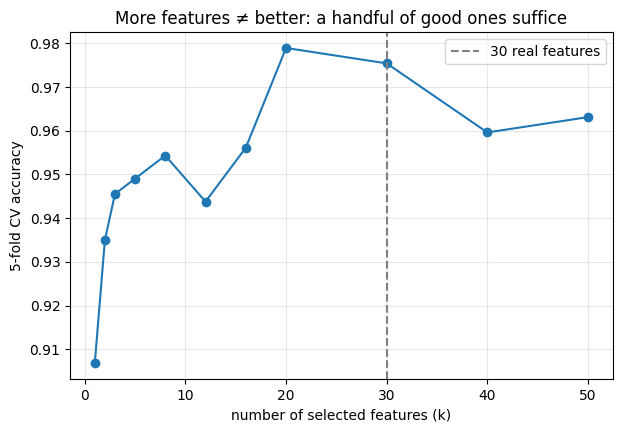

best k = 20 (acc 0.979)


In [8]:
ks = [1, 2, 3, 5, 8, 12, 16, 20, 30, 40, 50]
accs = [cross_val_score(make_pipeline(StandardScaler(), SelectKBest(f_classif, k=k), LogisticRegression(max_iter=5000)),
                        X, y, cv=5).mean() for k in ks]
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(ks, accs, "o-", color="#1f77b4")
ax.axvline(30, color="gray", ls="--", label="30 real features")
ax.set_xlabel("number of selected features (k)"); ax.set_ylabel("5-fold CV accuracy")
ax.set_title("More features ≠ better: a handful of good ones suffice"); ax.legend(); ax.grid(alpha=0.3)
plt.show()
print(f"best k = {ks[int(np.argmax(accs))]} (acc {max(accs):.3f})")

## 6. リークの再演 — 選択は交差検証の内側で

04 章の繰り返しですが最重要。**全データで特徴選択してから CV** すると、テストの情報が選択に漏れて
スコアが楽観的になります。**純粋なノイズ**(信号ゼロ)で確認します。正しくは選択を `Pipeline` に入れる。

In [9]:
rng = np.random.default_rng(1)
Xn = rng.standard_normal((120, 1000))   # pure noise
yn = rng.integers(0, 2, 120)            # random labels

# WRONG: select using all labels, then CV.
Xsel = SelectKBest(f_classif, k=20).fit_transform(Xn, yn)
wrong = cross_val_score(LogisticRegression(max_iter=2000), Xsel, yn, cv=5).mean()
# RIGHT: selection inside the pipeline (refit per fold).
right = cross_val_score(make_pipeline(SelectKBest(f_classif, k=20), LogisticRegression(max_iter=2000)), Xn, yn, cv=5).mean()
print(f"select-then-CV (LEAKY): {wrong:.3f}   <- predictive on pure noise (!)")
print(f"selection inside pipe : {right:.3f}   <- correctly ~0.5")

select-then-CV (LEAKY): 0.767   <- predictive on pure noise (!)
selection inside pipe : 0.508   <- correctly ~0.5


## 7. 選択の安定性

特徴選択は標本に敏感です。ブートストラップで何度も選び、**毎回選ばれる特徴**ほど信頼できます
(常連はたいてい本物、ノイズはたまにしか入らない)。

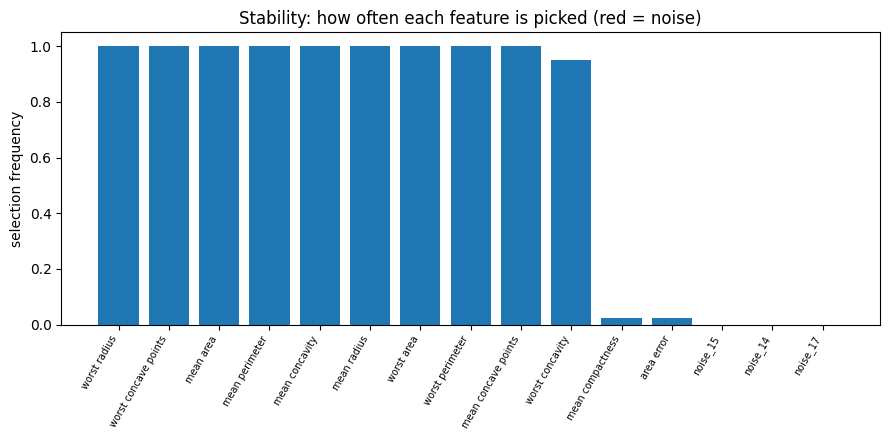

In [10]:
counts = np.zeros(X.shape[1])
B = 40
for b in range(B):
    idx = rng.integers(0, len(X), len(X))
    s = SelectKBest(f_classif, k=10).fit(StandardScaler().fit_transform(X[idx]), y[idx])
    counts[s.get_support()] += 1
freq = counts / B
top = np.argsort(freq)[::-1][:15]
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(range(len(top)), freq[top], color=["#1f77b4" if "noise" not in feat_names[i] else "#d62728" for i in top])
ax.set_xticks(range(len(top))); ax.set_xticklabels([feat_names[i] for i in top], rotation=60, ha="right", fontsize=7)
ax.set_ylabel("selection frequency"); ax.set_title("Stability: how often each feature is picked (red = noise)")
plt.tight_layout(); plt.show()

## 8. まとめ

- 特徴選択は **過学習を減らし・速く・解釈しやすく** する。多ければ良いわけではない。
- **Filter**(速い・個別)→ **Embedded**(L1/木・効率的)→ **Wrapper**(RFE/RFECV・高精度だが重い)の順に試すと効率的。
- どの手法でも **選択は CV の内側(訓練のみ)**。全データで選ぶとリーク(純ノイズでも高スコアが出る)。
- 選択の **安定性** を見る。毎回選ばれる特徴ほど信頼できる。
- 困ったら、まず L1 ロジスティック or 木の重要度 + `SelectFromModel`、検証で特徴数を決める。

## 9. Exercises

1. `mutual_info_classif` で選んだ上位 k と `f_classif` の上位 k を比べ、非線形特徴で差が出るか調べよ。
2. RFECV の `step` を 1 と 5 にして、選ばれる特徴数と計算時間の違いを見よ。
3. L1 ロジスティックの `C` を下げると残る特徴数がどう減るか観察せよ。
4. 性能 vs 特徴数の曲線で、ノイズ特徴の本数を 50 に増やすと最適 k がどう動くか。
5. (発展)安定性のブートストラップで、ノイズ特徴の選択頻度の上限はどのくらいか(偶然の上限)を見積もれ。

## 10. Common Mistakes

- **全データで特徴選択 → その後 CV。** リーク。必ず `Pipeline` 内で。
- **filter だけに頼る。** 相互作用を見落とす。wrapper/embedded と併用。
- **1 回の選択結果を信じる。** 標本依存。安定性を確認。
- **選択しすぎ/しなさすぎ。** 性能 vs 特徴数の曲線と検証で決める。